In [ ]:
# ====================================================
# STEP 0: Setup (Install & Drive Mount)
# ====================================================
!pip install torch torchvision matplotlib scikit-learn

import os
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Path to dataset zip file in Drive (upload once)
ZIP_PATH = "/content/drive/MyDrive/waste/waste_dataset.zip"

# Unzip into Colab runtime
!unzip -qo $ZIP_PATH -d /content/

# Dataset root directory after unzip
DATASET_DIR = "/content/waste_dataset"

Mounted at /content/drive


In [ ]:
# ====================================================
# STEP 1: Label Mapping (On the Fly)
# ====================================================
all_classes = [
    "battery", "biological", "brown-glass", "cardboard", "clothes",
    "green-glass", "metal", "paper", "plastic", "shoes",
    "trash", "white-glass"
]

group_mapping = {
    "battery": "Non-Recyclable",
    "biological": "Non-Recyclable",
    "trash": "Non-Recyclable",
    "clothes": "Non-Recyclable",
    "shoes": "Non-Recyclable",

    "brown-glass": "Recyclable",
    "green-glass": "Recyclable",
    "white-glass": "Recyclable",
    "cardboard": "Recyclable",
    "paper": "Recyclable",
    "plastic": "Recyclable",
    "metal": "Recyclable"
}

class_names = ["Non-Recyclable", "Recyclable"]

In [ ]:
# ====================================================
# STEP 2: Dataset & Preprocessing
# ====================================================
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

class WasteDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
# ====================================================
# STEP 3: Prepare Train/Test Split
# ====================================================
file_paths = []
labels = []

for class_name in all_classes:
    class_dir = os.path.join(DATASET_DIR, class_name)
    files = glob.glob(class_dir + "/*.jpg")  # change to *.png if needed
    for f in files:
        file_paths.append(f)
        labels.append(class_names.index(group_mapping[class_name]))

combined = list(zip(file_paths, labels))
random.shuffle(combined)
file_paths, labels = zip(*combined)

split_idx = int(0.8 * len(file_paths))
train_files, test_files = file_paths[:split_idx], file_paths[split_idx:]
train_labels, test_labels = labels[:split_idx], labels[split_idx:]

train_dataset = WasteDataset(train_files, train_labels, transform=train_transform)
test_dataset  = WasteDataset(test_files, test_labels, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train size:", len(train_dataset), "Test size:", len(test_dataset))

Train size: 12412 Test size: 3103


In [ ]:
# ====================================================
# STEP 4: Load ResNet18
# ====================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)

# Freeze early layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


In [ ]:
# ====================================================
# STEP 5.1: Training Setup
# ====================================================
criterion = nn.CrossEntropyLoss()

# ====================================================
# STEP 5.2: Hyperparameter Search
# ====================================================
learning_rates = [0.1, 0.01, 0.001, 0.0005, 0.0001]
optimizers_to_try = ["Adam", "SGD"]

results = []  # to store results for comparison

def train_and_evaluate(model, optimizer, criterion, train_loader, test_loader, epochs, lr, opt_name):
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        print(f"[{opt_name}] LR={lr} | Epoch {epoch+1}/{epochs}, "
              f"Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%")

    # Evaluate after training
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    test_acc = 100 * correct / total
    print(f"✅ [{opt_name}] LR={lr} | Test Accuracy: {test_acc:.2f}%\n")
    results.append((opt_name, lr, test_acc))

In [ ]:
# ====================================================
# STEP 6: Run Hyperparameter Search
# ====================================================
for opt_name in optimizers_to_try:
    for lr in learning_rates:
        # Reload fresh ResNet18 each time
        model = models.resnet18(pretrained=True)
        for param in model.parameters():
            param.requires_grad = False
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, 2)
        model = model.to(device)

        # Define optimizer
        if opt_name == "Adam":
            optimizer = optim.Adam(model.fc.parameters(), lr=lr)
        elif opt_name == "SGD":
            optimizer = optim.SGD(model.fc.parameters(), lr=lr, momentum=0.9)

        # Train + Evaluate
        train_and_evaluate(model, optimizer, criterion, train_loader, test_loader,
                           epochs=3, lr=lr, opt_name=opt_name)

[Adam] LR=0.1 | Epoch 1/3, Loss: 1.8229, Train Acc: 86.15%
[Adam] LR=0.1 | Epoch 2/3, Loss: 1.9744, Train Acc: 88.93%
[Adam] LR=0.1 | Epoch 3/3, Loss: 2.2324, Train Acc: 89.20%
✅ [Adam] LR=0.1 | Test Accuracy: 94.13%

[Adam] LR=0.01 | Epoch 1/3, Loss: 0.3180, Train Acc: 87.94%
[Adam] LR=0.01 | Epoch 2/3, Loss: 0.2803, Train Acc: 89.95%
[Adam] LR=0.01 | Epoch 3/3, Loss: 0.3257, Train Acc: 90.15%
✅ [Adam] LR=0.01 | Test Accuracy: 94.20%

[Adam] LR=0.001 | Epoch 1/3, Loss: 0.2903, Train Acc: 87.69%
[Adam] LR=0.001 | Epoch 2/3, Loss: 0.2060, Train Acc: 91.56%
[Adam] LR=0.001 | Epoch 3/3, Loss: 0.2005, Train Acc: 91.70%
✅ [Adam] LR=0.001 | Test Accuracy: 94.71%

[Adam] LR=0.0005 | Epoch 1/3, Loss: 0.3238, Train Acc: 85.54%
[Adam] LR=0.0005 | Epoch 2/3, Loss: 0.2260, Train Acc: 91.27%
[Adam] LR=0.0005 | Epoch 3/3, Loss: 0.2077, Train Acc: 91.78%
✅ [Adam] LR=0.0005 | Test Accuracy: 94.84%

[Adam] LR=0.0001 | Epoch 1/3, Loss: 0.4812, Train Acc: 76.43%
[Adam] LR=0.0001 | Epoch 2/3, Loss: 0.3419


=== Summary of Hyperparameter Search ===
  Optimizer      LR    TestAcc
0      Adam  0.1000  94.134708
1      Adam  0.0100  94.199162
2      Adam  0.0010  94.714792
3      Adam  0.0005  94.843700
4      Adam  0.0001  92.072188
5       SGD  0.1000  94.940380
6       SGD  0.0100  93.683532
7       SGD  0.0010  95.037061
8       SGD  0.0005  94.295843
9       SGD  0.0001  91.782146


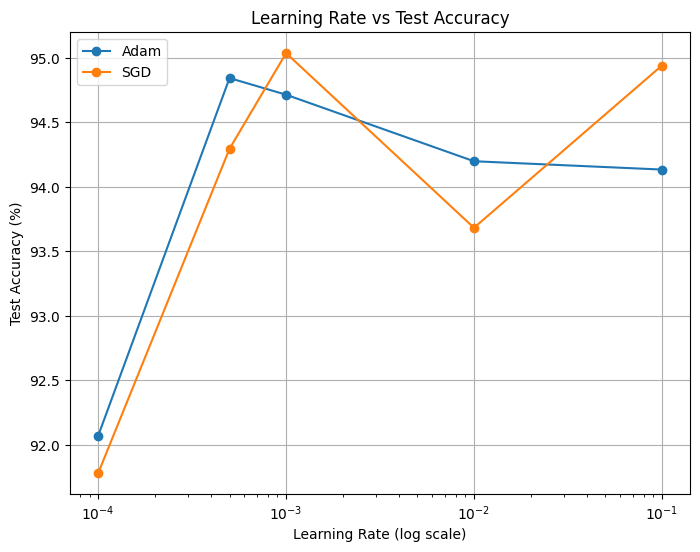

In [ ]:
# ====================================================
# STEP 7: Show Results + Plot
# ====================================================
import pandas as pd

# Convert results into a DataFrame for easy plotting
df = pd.DataFrame(results, columns=["Optimizer", "LR", "TestAcc"])

print("\n=== Summary of Hyperparameter Search ===")
print(df)

# Plot: LR vs Test Accuracy for each optimizer
plt.figure(figsize=(8, 6))
for opt_name in df["Optimizer"].unique():
    subset = df[df["Optimizer"] == opt_name]
    plt.plot(subset["LR"], subset["TestAcc"], marker="o", label=opt_name)

plt.xscale("log")  # since LR values span orders of magnitude
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Test Accuracy (%)")
plt.title("Learning Rate vs Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ====================================================
# STEP 8: Save Model to Drive
# ====================================================
SAVE_PATH = "/content/drive/MyDrive/waste/waste_classifier_resnet18.pth"
torch.save(model.state_dict(), SAVE_PATH)
print(f"✅ Model saved to {SAVE_PATH}")

✅ Model saved to /content/drive/MyDrive/waste/waste_classifier_resnet18.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🔄 Retraining with SGD, lr=0.001, epochs=10


100%|██████████| 388/388 [00:45<00:00,  8.57it/s]

Epoch 1/10, Loss: 0.2951, Train Acc: 87.45%


Test Accuracy: 92.94%
                precision    recall  f1-score   support

Non-Recyclable       0.98      0.91      0.94      2031
    Recyclable       0.85      0.96      0.90      1072

      accuracy                           0.93      3103
     macro avg       0.92      0.94      0.92      3103
  weighted avg       0.94      0.93      0.93      3103



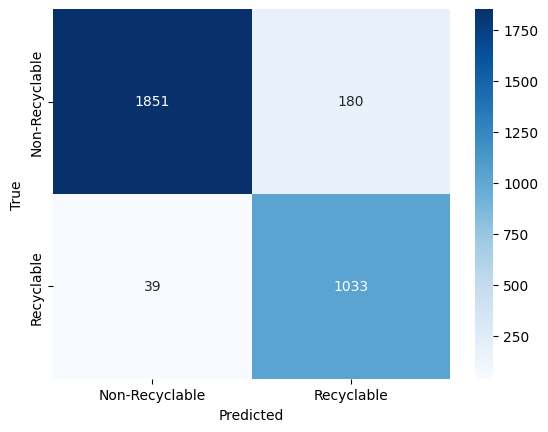

100%|██████████| 388/388 [00:45<00:00,  8.61it/s]

Epoch 2/10, Loss: 0.2137, Train Acc: 91.35%


Test Accuracy: 94.23%
                precision    recall  f1-score   support

Non-Recyclable       0.93      0.99      0.96      2031
    Recyclable       0.97      0.86      0.91      1072

      accuracy                           0.94      3103
     macro avg       0.95      0.92      0.93      3103
  weighted avg       0.94      0.94      0.94      3103



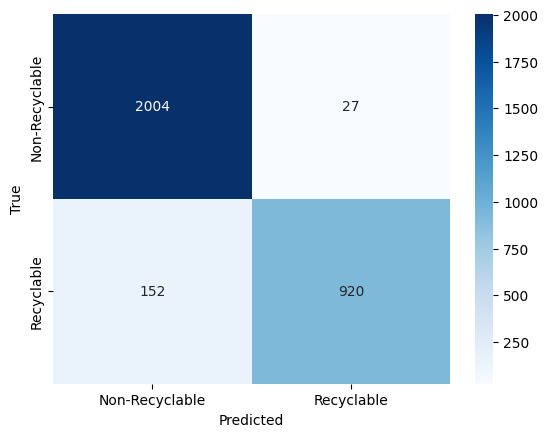

100%|██████████| 388/388 [00:45<00:00,  8.61it/s]

Epoch 3/10, Loss: 0.1991, Train Acc: 91.73%


Test Accuracy: 94.94%
                precision    recall  f1-score   support

Non-Recyclable       0.96      0.97      0.96      2031
    Recyclable       0.93      0.92      0.93      1072

      accuracy                           0.95      3103
     macro avg       0.95      0.94      0.94      3103
  weighted avg       0.95      0.95      0.95      3103



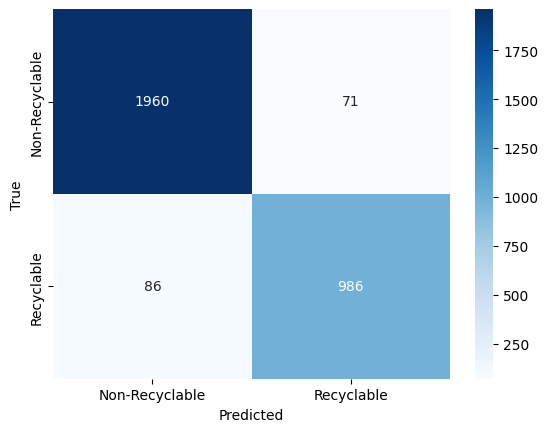

100%|██████████| 388/388 [00:45<00:00,  8.59it/s]

Epoch 4/10, Loss: 0.1935, Train Acc: 91.81%


Test Accuracy: 94.13%
                precision    recall  f1-score   support

Non-Recyclable       0.93      0.99      0.96      2031
    Recyclable       0.97      0.86      0.91      1072

      accuracy                           0.94      3103
     macro avg       0.95      0.92      0.93      3103
  weighted avg       0.94      0.94      0.94      3103



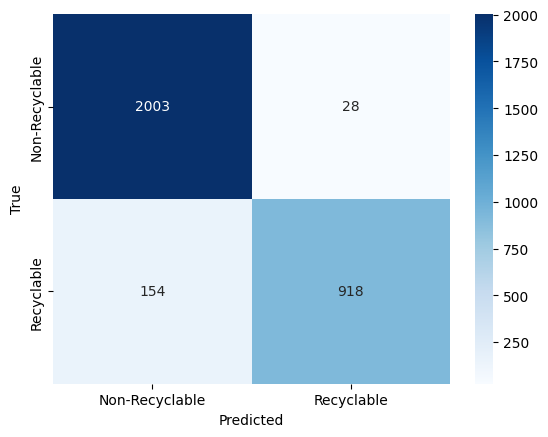

100%|██████████| 388/388 [00:45<00:00,  8.52it/s]

Epoch 5/10, Loss: 0.1861, Train Acc: 92.53%


Test Accuracy: 95.20%
                precision    recall  f1-score   support

Non-Recyclable       0.95      0.97      0.96      2031
    Recyclable       0.95      0.91      0.93      1072

      accuracy                           0.95      3103
     macro avg       0.95      0.94      0.95      3103
  weighted avg       0.95      0.95      0.95      3103



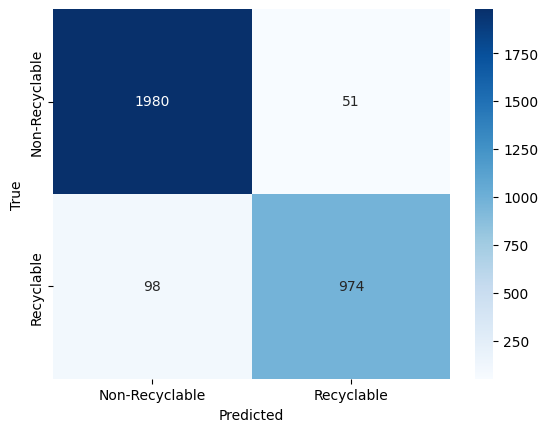

100%|██████████| 388/388 [00:45<00:00,  8.51it/s]

Epoch 6/10, Loss: 0.1810, Train Acc: 92.72%


Test Accuracy: 94.39%
                precision    recall  f1-score   support

Non-Recyclable       0.93      0.99      0.96      2031
    Recyclable       0.97      0.87      0.91      1072

      accuracy                           0.94      3103
     macro avg       0.95      0.93      0.94      3103
  weighted avg       0.95      0.94      0.94      3103



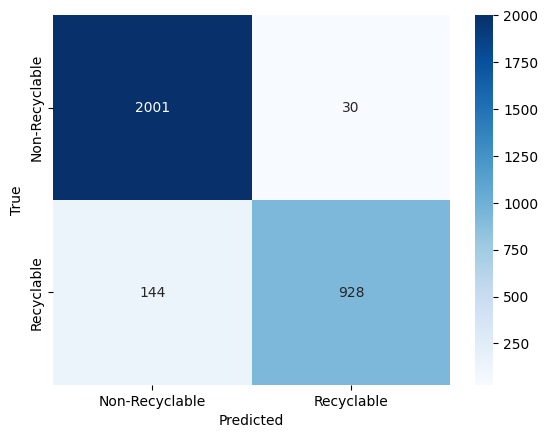

100%|██████████| 388/388 [00:45<00:00,  8.53it/s]

Epoch 7/10, Loss: 0.1897, Train Acc: 92.27%


Test Accuracy: 95.33%
                precision    recall  f1-score   support

Non-Recyclable       0.96      0.97      0.96      2031
    Recyclable       0.94      0.93      0.93      1072

      accuracy                           0.95      3103
     macro avg       0.95      0.95      0.95      3103
  weighted avg       0.95      0.95      0.95      3103



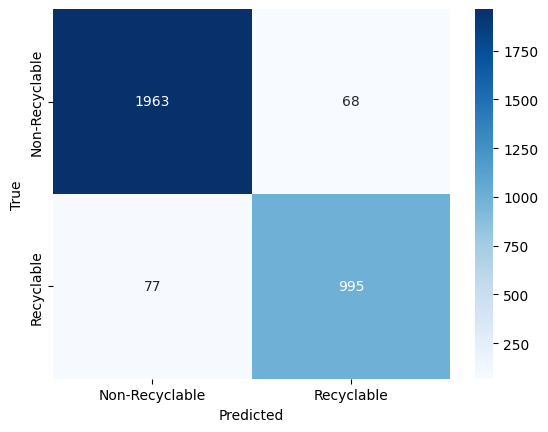

100%|██████████| 388/388 [00:45<00:00,  8.51it/s]

Epoch 8/10, Loss: 0.1791, Train Acc: 92.62%


Test Accuracy: 95.29%
                precision    recall  f1-score   support

Non-Recyclable       0.96      0.97      0.96      2031
    Recyclable       0.95      0.92      0.93      1072

      accuracy                           0.95      3103
     macro avg       0.95      0.94      0.95      3103
  weighted avg       0.95      0.95      0.95      3103



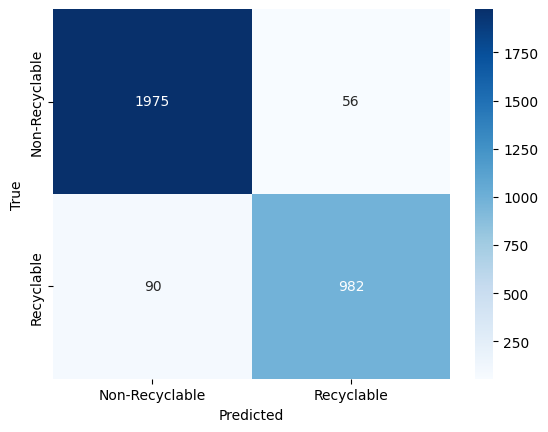

100%|██████████| 388/388 [00:45<00:00,  8.51it/s]

Epoch 9/10, Loss: 0.1717, Train Acc: 93.06%


Test Accuracy: 94.81%
                precision    recall  f1-score   support

Non-Recyclable       0.94      0.99      0.96      2031
    Recyclable       0.97      0.88      0.92      1072

      accuracy                           0.95      3103
     macro avg       0.95      0.93      0.94      3103
  weighted avg       0.95      0.95      0.95      3103



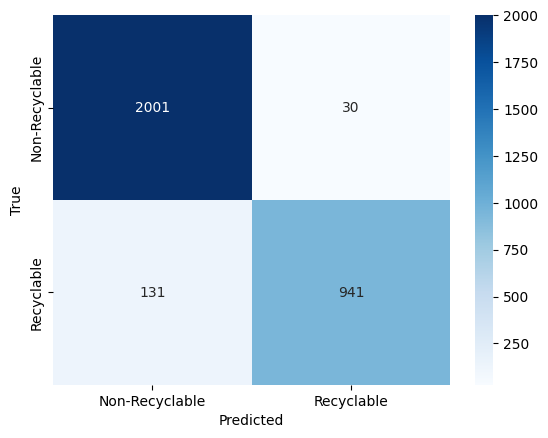

100%|██████████| 388/388 [00:46<00:00,  8.39it/s]

Epoch 10/10, Loss: 0.1756, Train Acc: 92.76%


Test Accuracy: 95.26%
                precision    recall  f1-score   support

Non-Recyclable       0.95      0.98      0.96      2031
    Recyclable       0.96      0.90      0.93      1072

      accuracy                           0.95      3103
     macro avg       0.95      0.94      0.95      3103
  weighted avg       0.95      0.95      0.95      3103



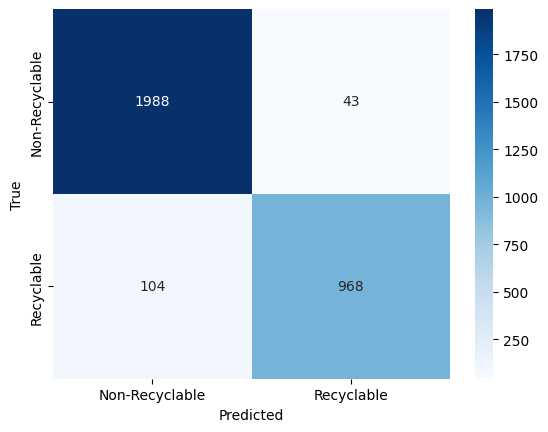

✅ Final model saved to /content/drive/MyDrive/waste_classifier_resnet18_final.pth


In [ ]:
# ====================================================
# STEP 9: Retrain Best Model with Confusion Matrix
# ====================================================

best_lr = 0.001
best_optimizer = "SGD"
max_epochs = 10          # you can set 5 or 10

# Reload fresh ResNet18
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

# Optimizer setup
if best_optimizer == "Adam":
    optimizer = optim.Adam(model.fc.parameters(), lr=best_lr)
else:
    optimizer = optim.SGD(model.fc.parameters(), lr=best_lr, momentum=0.9)

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs):
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Forward
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%")

        evaluate(model, test_loader)

def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Train again
print(f"🔄 Retraining with {best_optimizer}, lr={best_lr}, epochs={max_epochs}")
train_model(model, train_loader, test_loader, criterion, optimizer, epochs=max_epochs)

# Save final model
FINAL_SAVE_PATH = "/content/drive/MyDrive/waste_classifier_resnet18_final.pth"
torch.save(model.state_dict(), FINAL_SAVE_PATH)
print(f"✅ Final model saved to {FINAL_SAVE_PATH}")



=== Training EfficientNet-B0 ===


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 149MB/s]
100%|██████████| 388/388 [00:45<00:00,  8.48it/s]

Epoch 1/10, Loss: 0.3573, Train Acc: 85.39%


Test Accuracy: 92.85%
                precision    recall  f1-score   support

Non-Recyclable       0.94      0.95      0.95      2031
    Recyclable       0.91      0.88      0.89      1072

      accuracy                           0.93      3103
     macro avg       0.92      0.92      0.92      3103
  weighted avg       0.93      0.93      0.93      3103



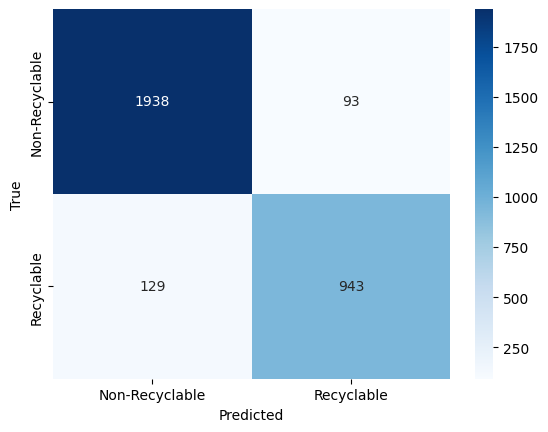

100%|██████████| 388/388 [00:45<00:00,  8.46it/s]

Epoch 2/10, Loss: 0.2505, Train Acc: 90.72%


Test Accuracy: 94.36%
                precision    recall  f1-score   support

Non-Recyclable       0.95      0.97      0.96      2031
    Recyclable       0.94      0.89      0.92      1072

      accuracy                           0.94      3103
     macro avg       0.94      0.93      0.94      3103
  weighted avg       0.94      0.94      0.94      3103



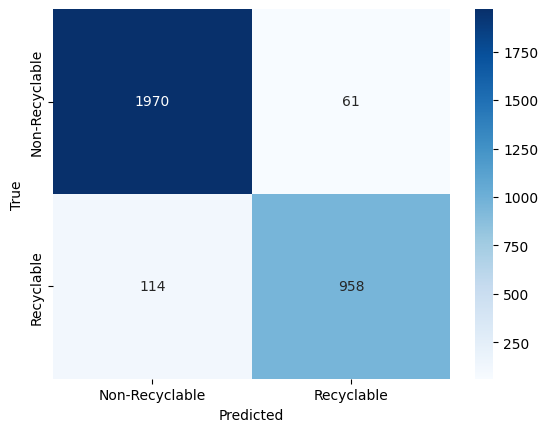

100%|██████████| 388/388 [00:46<00:00,  8.38it/s]

Epoch 3/10, Loss: 0.2242, Train Acc: 91.71%


Test Accuracy: 94.81%
                precision    recall  f1-score   support

Non-Recyclable       0.96      0.96      0.96      2031
    Recyclable       0.92      0.93      0.93      1072

      accuracy                           0.95      3103
     macro avg       0.94      0.94      0.94      3103
  weighted avg       0.95      0.95      0.95      3103



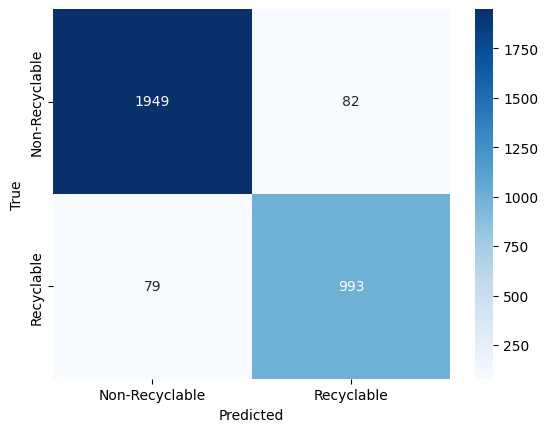

100%|██████████| 388/388 [00:46<00:00,  8.41it/s]

Epoch 4/10, Loss: 0.2070, Train Acc: 92.10%


Test Accuracy: 95.13%
                precision    recall  f1-score   support

Non-Recyclable       0.97      0.96      0.96      2031
    Recyclable       0.92      0.94      0.93      1072

      accuracy                           0.95      3103
     macro avg       0.94      0.95      0.95      3103
  weighted avg       0.95      0.95      0.95      3103



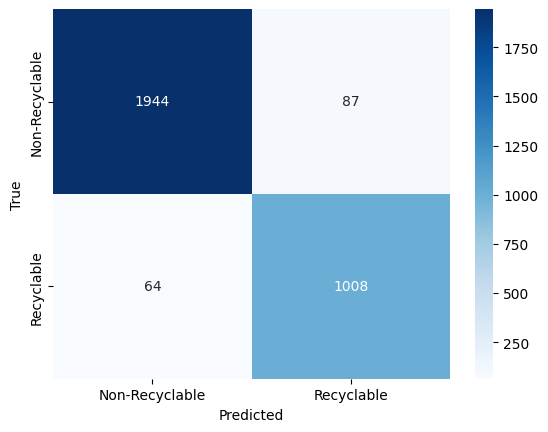

100%|██████████| 388/388 [00:46<00:00,  8.36it/s]

Epoch 5/10, Loss: 0.2057, Train Acc: 92.21%


Test Accuracy: 95.46%
                precision    recall  f1-score   support

Non-Recyclable       0.96      0.97      0.97      2031
    Recyclable       0.94      0.93      0.93      1072

      accuracy                           0.95      3103
     macro avg       0.95      0.95      0.95      3103
  weighted avg       0.95      0.95      0.95      3103



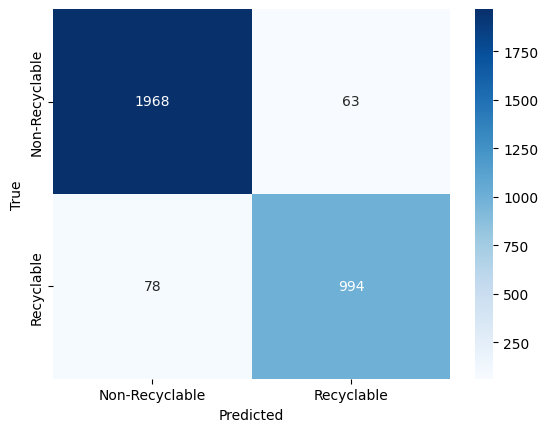

100%|██████████| 388/388 [00:46<00:00,  8.30it/s]

Epoch 6/10, Loss: 0.1983, Train Acc: 92.47%


Test Accuracy: 95.17%
                precision    recall  f1-score   support

Non-Recyclable       0.96      0.97      0.96      2031
    Recyclable       0.94      0.92      0.93      1072

      accuracy                           0.95      3103
     macro avg       0.95      0.94      0.95      3103
  weighted avg       0.95      0.95      0.95      3103



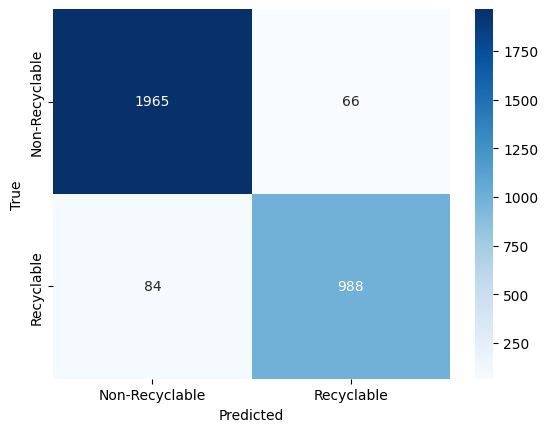

100%|██████████| 388/388 [00:47<00:00,  8.14it/s]

Epoch 7/10, Loss: 0.1929, Train Acc: 92.70%


Test Accuracy: 95.49%
                precision    recall  f1-score   support

Non-Recyclable       0.96      0.97      0.97      2031
    Recyclable       0.94      0.92      0.93      1072

      accuracy                           0.95      3103
     macro avg       0.95      0.95      0.95      3103
  weighted avg       0.95      0.95      0.95      3103



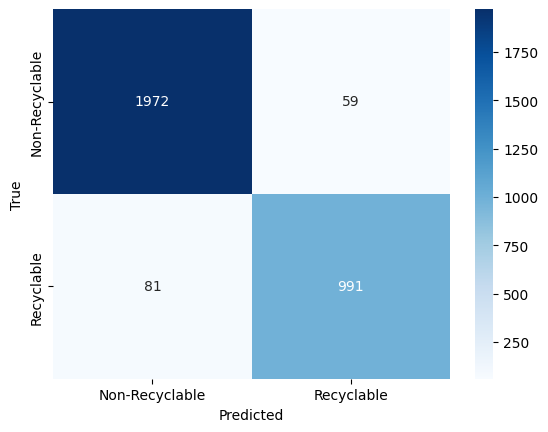

100%|██████████| 388/388 [00:47<00:00,  8.17it/s]

Epoch 8/10, Loss: 0.1878, Train Acc: 92.60%


Test Accuracy: 95.71%
                precision    recall  f1-score   support

Non-Recyclable       0.96      0.97      0.97      2031
    Recyclable       0.94      0.93      0.94      1072

      accuracy                           0.96      3103
     macro avg       0.95      0.95      0.95      3103
  weighted avg       0.96      0.96      0.96      3103



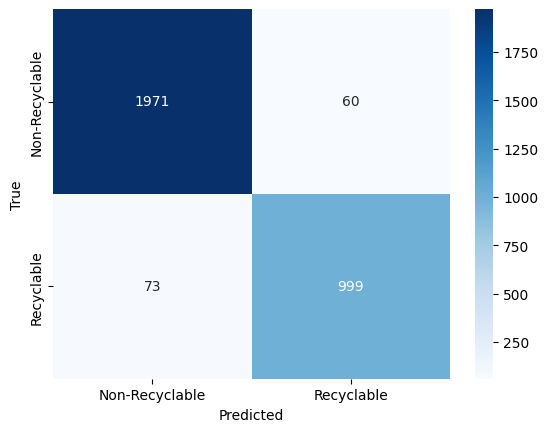

100%|██████████| 388/388 [00:47<00:00,  8.11it/s]

Epoch 9/10, Loss: 0.1946, Train Acc: 92.30%


Test Accuracy: 95.75%
                precision    recall  f1-score   support

Non-Recyclable       0.97      0.96      0.97      2031
    Recyclable       0.93      0.94      0.94      1072

      accuracy                           0.96      3103
     macro avg       0.95      0.95      0.95      3103
  weighted avg       0.96      0.96      0.96      3103



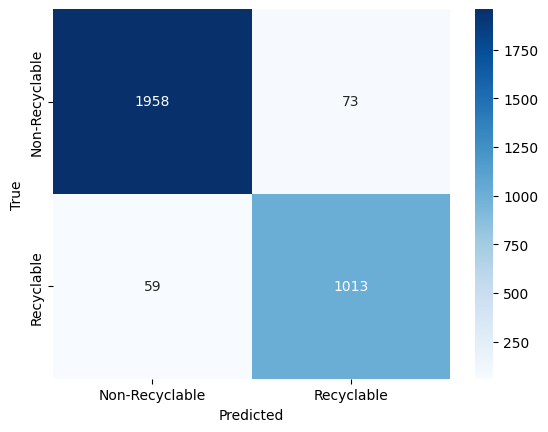

100%|██████████| 388/388 [00:46<00:00,  8.34it/s]

Epoch 10/10, Loss: 0.1828, Train Acc: 92.93%


Test Accuracy: 95.71%
                precision    recall  f1-score   support

Non-Recyclable       0.96      0.98      0.97      2031
    Recyclable       0.96      0.92      0.94      1072

      accuracy                           0.96      3103
     macro avg       0.96      0.95      0.95      3103
  weighted avg       0.96      0.96      0.96      3103



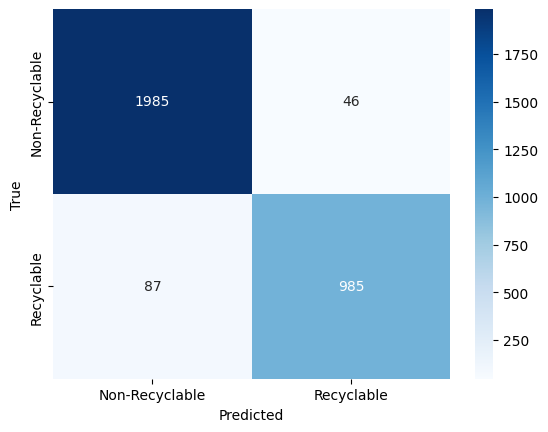

✅ Final EfficientNet-B0 model saved to /content/drive/MyDrive/waste_classifier_efficientnetb0_final.pth


In [ ]:
# ====================================================
# STEP 10: EfficientNet-B0 Training
# ====================================================
print("\n=== Training EfficientNet-B0 ===")

# Load EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)

# Freeze early layers
for param in model.parameters():
    param.requires_grad = False

# Replace final classifier layer
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)
model = model.to(device)

# Optimizer setup (use best found: SGD + lr=0.001)
optimizer = optim.SGD(model.classifier[1].parameters(), lr=0.001, momentum=0.9)

# Train EfficientNet-B0
train_model(model, train_loader, test_loader, criterion, optimizer, epochs=max_epochs)

# Save EfficientNet-B0 model
FINAL_SAVE_PATH_EFF = "/content/drive/MyDrive/waste_classifier_efficientnetb0_final.pth"
torch.save(model.state_dict(), FINAL_SAVE_PATH_EFF)
print(f"✅ Final EfficientNet-B0 model saved to {FINAL_SAVE_PATH_EFF}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



=== Model Comparison ===
             Model  Test Accuracy (%)
0         ResNet18          93.264583
1  EfficientNet-B0          95.810506


/tmp/ipython-input-2099035576.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Test Accuracy (%)", data=comparison_df, palette="viridis")


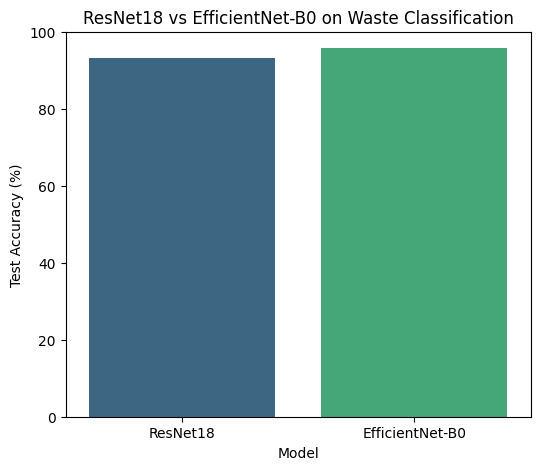

In [ ]:
# ====================================================
# STEP 11: Compare ResNet18 vs EfficientNet-B0
# ====================================================

# Function to get final test accuracy
def get_final_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

# Reload trained models from saved files
resnet18_model = models.resnet18(pretrained=False)
num_features = resnet18_model.fc.in_features
resnet18_model.fc = nn.Linear(num_features, 2)
resnet18_model.load_state_dict(torch.load("/content/drive/MyDrive/waste_classifier_resnet18_final.pth"))
resnet18_model = resnet18_model.to(device)

effnet_model = models.efficientnet_b0(pretrained=False)
num_features = effnet_model.classifier[1].in_features
effnet_model.classifier[1] = nn.Linear(num_features, 2)
effnet_model.load_state_dict(torch.load("/content/drive/MyDrive/waste_classifier_efficientnetb0_final.pth"))
effnet_model = effnet_model.to(device)

# Compute accuracies
resnet18_acc = get_final_accuracy(resnet18_model, test_loader)
effnet_acc   = get_final_accuracy(effnet_model, test_loader)

# Put in DataFrame
comparison_df = pd.DataFrame({
    "Model": ["ResNet18", "EfficientNet-B0"],
    "Test Accuracy (%)": [resnet18_acc, effnet_acc]
})

print("\n=== Model Comparison ===")
print(comparison_df)

# Plot comparison
plt.figure(figsize=(6, 5))
sns.barplot(x="Model", y="Test Accuracy (%)", data=comparison_df, palette="viridis")
plt.title("ResNet18 vs EfficientNet-B0 on Waste Classification")
plt.ylim(0, 100)
plt.show()


Found 22 images in the new dataset.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Evaluating EfficientNet-B0 on the new dataset (my_waste2.zip):
Test Accuracy: 95.45%
                precision    recall  f1-score   support

Non-Recyclable       1.00      0.92      0.96        13
    Recyclable       0.90      1.00      0.95         9

      accuracy                           0.95        22
     macro avg       0.95      0.96      0.95        22
  weighted avg       0.96      0.95      0.95        22



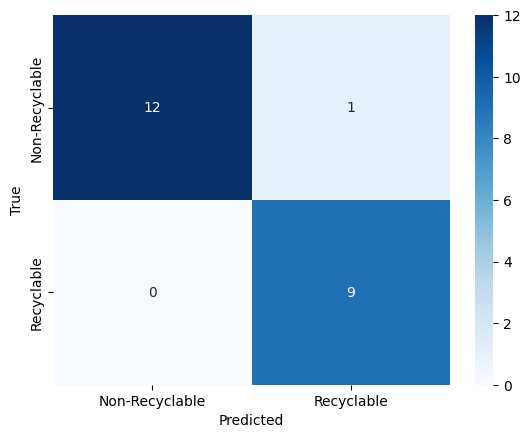

In [ ]:
# ====================================================
# STEP 12: Test EfficientNet-B0 on real photos! (my_waste2.zip)
# ====================================================

NEW_DATASET_ZIP_PATH_2 = "/content/drive/MyDrive/waste/my_waste2.zip"

# Unzip into Colab runtime
!unzip -qo $NEW_DATASET_ZIP_PATH_2 -d /content/

# Directory where the new dataset was unzipped
NEW_DATASET_DIR_2 = "/content/my_waste2"

# Prepare file paths and labels for the new dataset
new_file_paths_2 = []
new_labels_2 = []

class_names = ["Non-Recyclable", "Recyclable"]

# Collect images
for class_name in class_names:
    class_dir = os.path.join(NEW_DATASET_DIR_2, class_name)
    if os.path.exists(class_dir):
        files = glob.glob(class_dir + "/*.jpg") + glob.glob(class_dir + "/*.png")  # handle jpg/png
        for f in files:
            new_file_paths_2.append(f)
            new_labels_2.append(class_names.index(class_name))
    else:
        print(f"Warning: Directory '{class_dir}' not found in the new dataset.")

print("Found", len(new_file_paths_2), "images in the new dataset.")

# Dataset + DataLoader
if len(new_file_paths_2) > 0:
    new_dataset_2 = WasteDataset(new_file_paths_2, new_labels_2, transform=test_transform)
    new_loader_2 = DataLoader(new_dataset_2, batch_size=32, shuffle=False, num_workers=2)

    # ====================================================
    # Load trained EfficientNet-B0
    # ====================================================
    effnet_test_model = models.efficientnet_b0(pretrained=False)
    num_features = effnet_test_model.classifier[1].in_features
    effnet_test_model.classifier[1] = nn.Linear(num_features, 2)
    effnet_test_model.load_state_dict(torch.load("/content/drive/MyDrive/waste_classifier_efficientnetb0_final.pth"))
    effnet_test_model = effnet_test_model.to(device)

    # Evaluate EfficientNet-B0 on new dataset
    print("\nEvaluating EfficientNet-B0 on the new dataset (my_waste2.zip):")
    evaluate(effnet_test_model, new_loader_2)
else:
    print("No images found in the new dataset. Please check the path and file extensions.")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


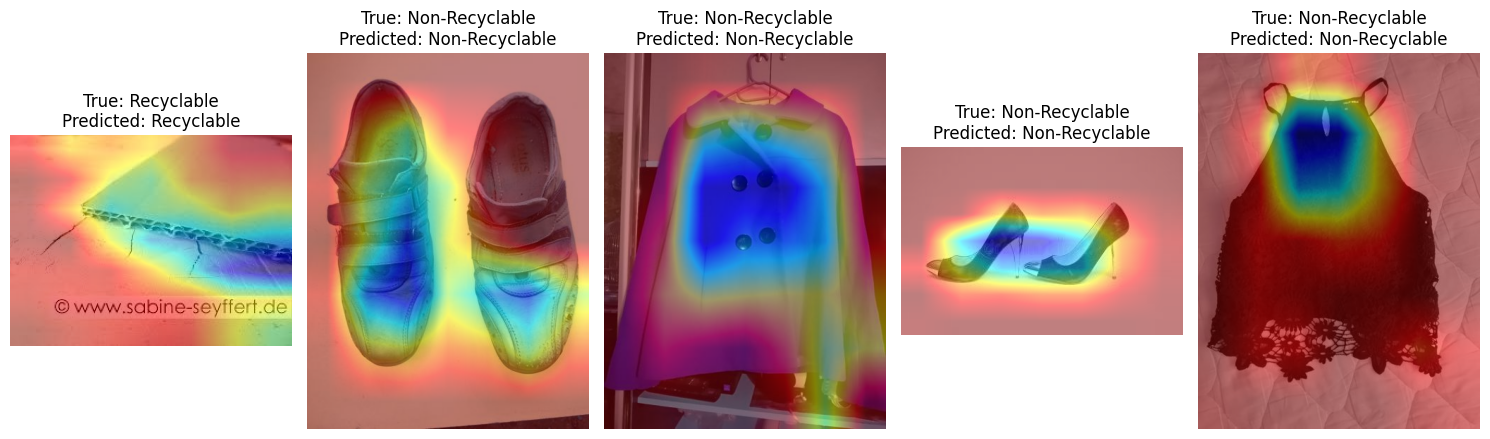

In [ ]:
# ====================================================
# STEP 15: Grad-CAM Visualization for Multiple Images
# ====================================================
import numpy as np
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image # Import preprocess_image
import matplotlib.pyplot as plt
import torch
import random
from PIL import Image

# Load the best model (EfficientNet-B0) - assuming this was the best from previous steps
effnet_test_model = models.efficientnet_b0(pretrained=False)
num_features = effnet_test_model.classifier[1].in_features
effnet_test_model.classifier[1] = nn.Linear(num_features, 2)
effnet_test_model.load_state_dict(torch.load("/content/drive/MyDrive/waste_classifier_efficientnetb0_final.pth"))
effnet_test_model = effnet_test_model.to(device)

# Define the target layer for Grad-CAM (usually the last convolutional layer)
# For EfficientNet-B0, a good candidate is the last block's convolution
target_layer = effnet_test_model.features[-1]

# Create a GradCAM object
cam = GradCAM(model=effnet_test_model, target_layers=[target_layer])

# Select a few sample images (e.g., 5 images)
num_images_to_show = 5
sample_indices = random.sample(range(len(test_files)), num_images_to_show)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(sample_indices):
    sample_image_path = test_files[idx]
    sample_label = test_labels[idx]

    # Load and preprocess the image using preprocess_image
    rgb_img = cv2.imread(sample_image_path, 1)[:, :, ::-1]
    rgb_img_float = np.float32(rgb_img) / 255 # Keep original float image for show_cam_on_image
    input_tensor = test_transform(Image.open(sample_image_path).convert("RGB")).unsqueeze(0) # Using test_transform as preprocess_image might not be compatible with the model's input

    # If your model requires the input to be on a specific device (e.g., GPU)
    input_tensor = input_tensor.to(device)

    # Define the target for Grad-CAM
    # To target the predicted class, you can do:
    # with torch.no_grad():
    #     output = effnet_test_model(input_tensor)
    #     predicted_class_index = output.argmax(dim=1).item()
    # targets = [ClassifierOutputTarget(predicted_class_index)]
    # Or to target a specific class (e.g., Recyclable = 1):
    # targets = [ClassifierOutputTarget(1)]
    targets = None # Use None to target the highest scoring output

    # Generate the CAM
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

    # In this example grayscale_cam has only one image in the batch:
    grayscale_cam = grayscale_cam[0, :]

    # Resize the heatmap to match the original image dimensions
    grayscale_cam = cv2.resize(grayscale_cam, (rgb_img.shape[1], rgb_img.shape[0]))

    # Expand dimensions of grayscale_cam to be 3D
    grayscale_cam = np.expand_dims(grayscale_cam, axis=-1)


    # Visualize the CAM
    cam_image = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True) # Use the float image and grayscale heatmap
    cam_image = cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR) # Convert back to BGR for displaying with cv2 if needed, though matplotlib uses RGB

    # Display the image and heatmap
    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(cam_image)
    plt.title(f"True: {class_names[sample_label]}\nPredicted: {class_names[effnet_test_model(input_tensor).argmax(dim=1).item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()